# Calibration Analysis

- [Parameters](#Parameters)
- [Data Loading](#Data-Loading)
- [Summary Statistics](#Summary-Statistics)
- [Visualizations](#Visualizations)
- [Best/Worst Cases](#Best-Worst-Cases)
- [Environment Info](#Environment-Info)

In [1]:
import os
import pandas as pd

# Parameters
date = '2024-02-19'
detector = 'w2e_in'
number = 0
project_root = os.environ["HORNSGATAN_HOME"]

if number > 0:
    postfix = f"{detector}_{date}_{number}"
else:
    postfix = f"{detector}_{date}"

data_path = os.path.join(project_root, "data/calibration_data", f"calibrated_data_{postfix}.csv")
print("Data path:", data_path)

Data path: /home/kaveh/projects/Hornsgatan/data/calibration_data/calibrated_data_w2e_in_2024-02-19.csv


In [2]:
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("Loaded data:", df.shape)
else:
    raise FileNotFoundError(f"File not found: {data_path}")
df.head()

Loaded data: (130, 10)


,veh_id,time_detector_sim,speed_detector_sim,speed_factor,time_detector_real,depart,departSpeed,speed_detector_real,delta_time,delta_speed
0,0_w2e_in,1.708315e+09,10.745803,1.40,1708315321,1708315283,19.4460,10.277778,-0.05,0.468025
1,1_w2e_in,1.708315e+09,11.934813,1.50,1708315387,1708315352,20.8350,11.666667,0.12,0.268147
2,2_w2e_in,1.708316e+09,4.660289,0.60,1708315727,1708315635,8.3340,5.555556,0.45,-0.895267
3,3_w2e_in,1.708316e+09,9.863534,1.25,1708315767,1708315725,17.3625,10.000000,0.24,-0.136466
4,4_w2e_in,1.708316e+09,11.398271,1.40,1708315773,1708315735,19.4460,11.111111,0.13,0.287160


In [3]:
# Show summary stats for error columns
error_cols = ["delta_time", "delta_speed"]
df[error_cols].describe()

,delta_time,delta_speed
count,130.000000,130.000000
mean,0.111692,0.434582
std,0.856667,1.149777
min,-3.530000,-2.529933
25%,-0.222500,-0.136427
50%,0.135000,0.131991
75%,0.260000,0.455315
max,4.540000,5.534136


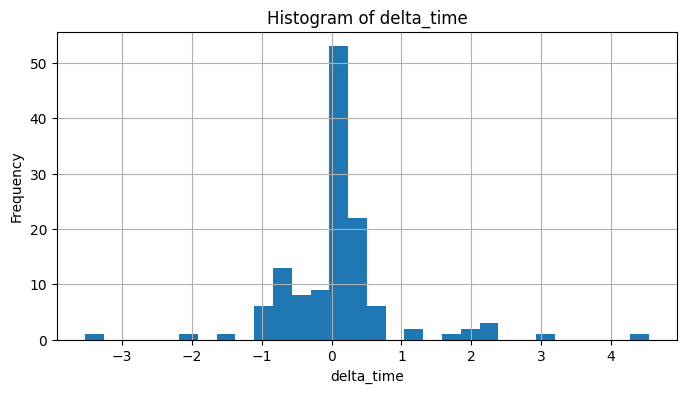

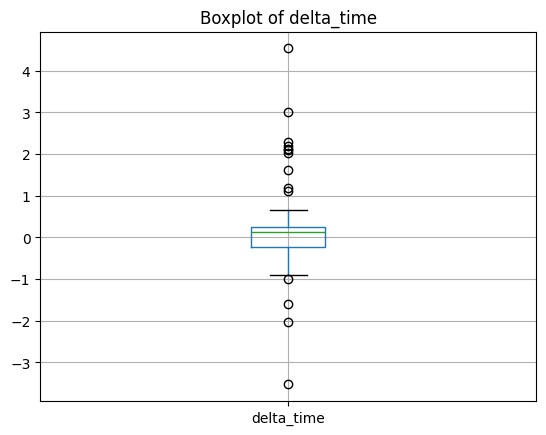

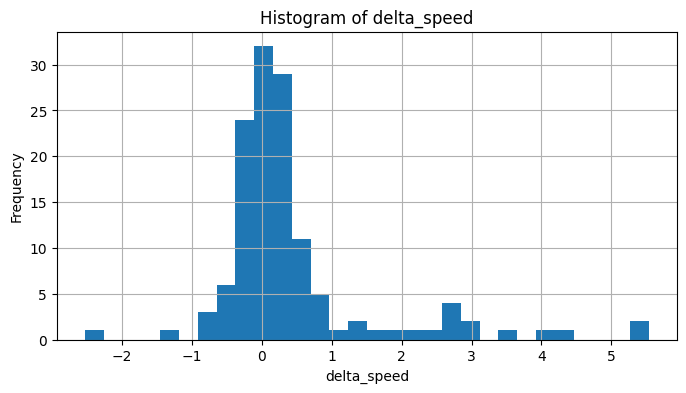

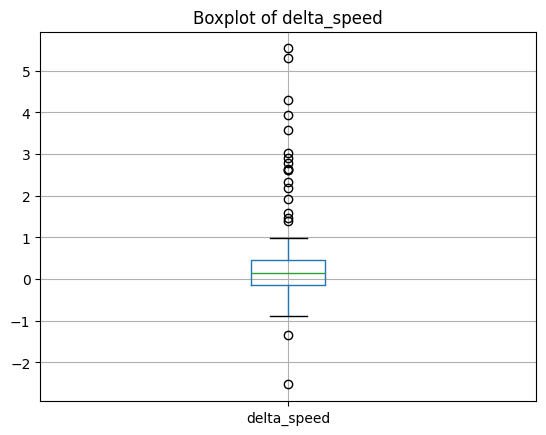

In [4]:
import matplotlib.pyplot as plt

for col in error_cols:
    plt.figure(figsize=(8,4))
    df[col].hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [5]:
# Show rows with smallest/largest delta_time
print("Smallest delta_time:")
display(df.nsmallest(5, "delta_time"))
print("Largest delta_time:")
display(df.nlargest(5, "delta_time"))

Smallest delta_time:


,veh_id,time_detector_sim,speed_detector_sim,speed_factor,time_detector_real,depart,departSpeed,speed_detector_real,delta_time,delta_speed
83,83_w2e_in,1.708321e+09,9.988883,1.25,1708321224,1708321178,17.3625,9.722222,-3.53,0.266661
35,35_w2e_in,1.708318e+09,7.797966,1.05,1708318016,1708317963,14.5845,7.500000,-2.04,0.297966
17,17_w2e_in,1.708317e+09,9.629275,1.25,1708316707,1708316663,17.3625,8.055556,-1.61,1.573719
18,18_w2e_in,1.708317e+09,9.544818,1.30,1708316908,1708316866,18.0570,8.888889,-1.00,0.655929
49,49_w2e_in,1.708319e+09,12.731919,1.65,1708319192,1708319159,22.9185,10.555556,-0.91,2.176363


Largest delta_time:


,veh_id,time_detector_sim,speed_detector_sim,speed_factor,time_detector_real,depart,departSpeed,speed_detector_real,delta_time,delta_speed
12,12_w2e_in,1.708316e+09,7.070758,0.95,1708316243,1708316191,13.1955,2.777778,4.54,4.292981
118,118_w2e_in,1.708322e+09,11.779801,2.50,1708322143,1708322113,34.7250,9.444444,3.02,2.335356
66,66_w2e_in,1.708320e+09,8.563722,1.15,1708320248,1708320204,15.9735,5.000000,2.29,3.563722
121,121_w2e_in,1.708322e+09,9.132303,1.25,1708322174,1708322133,17.3625,7.222222,2.19,1.910080
57,57_w2e_in,1.708320e+09,8.299761,1.05,1708319593,1708319544,14.5845,5.277778,2.13,3.021983


1. Distribution Plots (Seaborn)

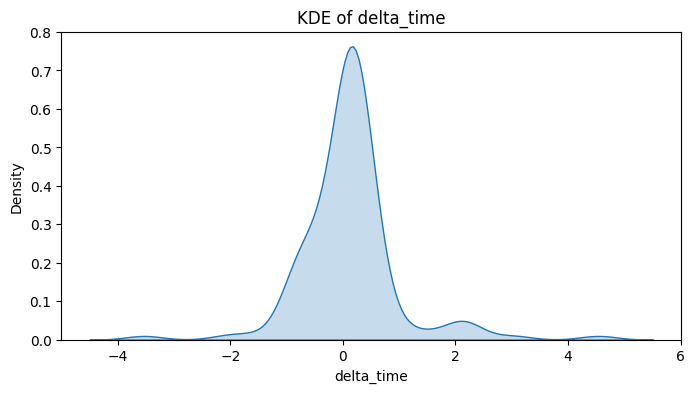

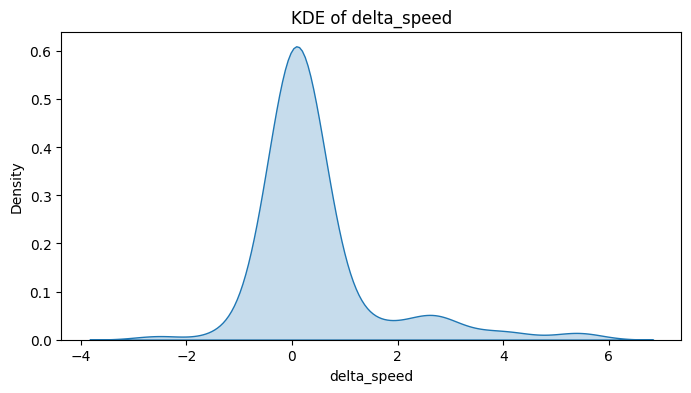

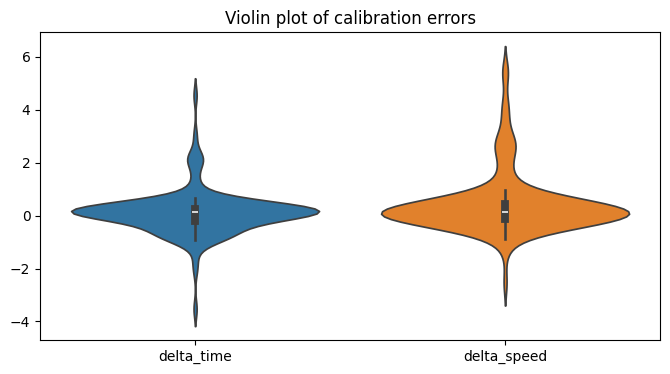

In [6]:
import seaborn as sns

# KDE plot for delta_time and delta_speed
for col in error_cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(df[col], fill=True)
    plt.title(f"KDE of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()

# Violin plot
plt.figure(figsize=(8,4))
sns.violinplot(data=df[error_cols])
plt.title("Violin plot of calibration errors")
plt.show()

2. Scatter Plot: Simulated vs. Real Values


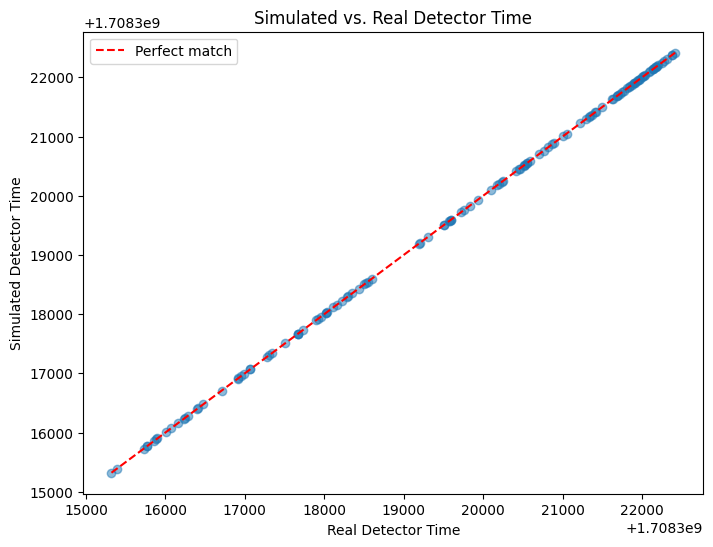

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(df['time_detector_real'], df['time_detector_sim'], alpha=0.5)
plt.plot([df['time_detector_real'].min(), df['time_detector_real'].max()],
         [df['time_detector_real'].min(), df['time_detector_real'].max()],
         'r--', label='Perfect match')
plt.xlabel('Real Detector Time')
plt.ylabel('Simulated Detector Time')
plt.title('Simulated vs. Real Detector Time')
plt.legend()
plt.show()

3. Error Over Time


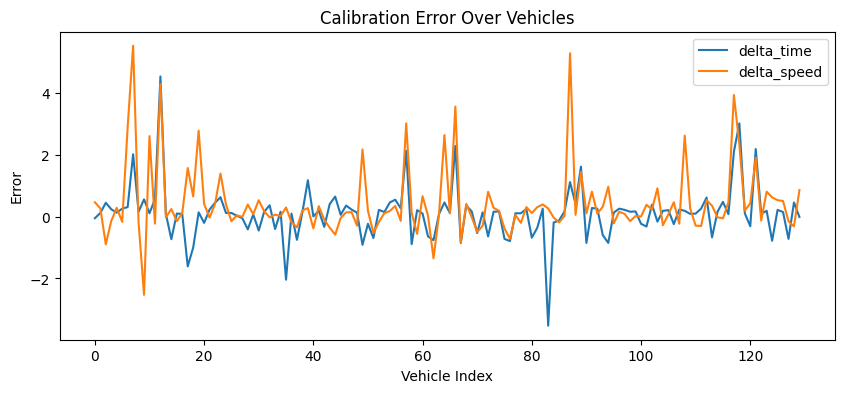

In [8]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df['delta_time'], label='delta_time')
plt.plot(df.index, df['delta_speed'], label='delta_speed')
plt.xlabel('Vehicle Index')
plt.ylabel('Error')
plt.title('Calibration Error Over Vehicles')
plt.legend()
plt.show()

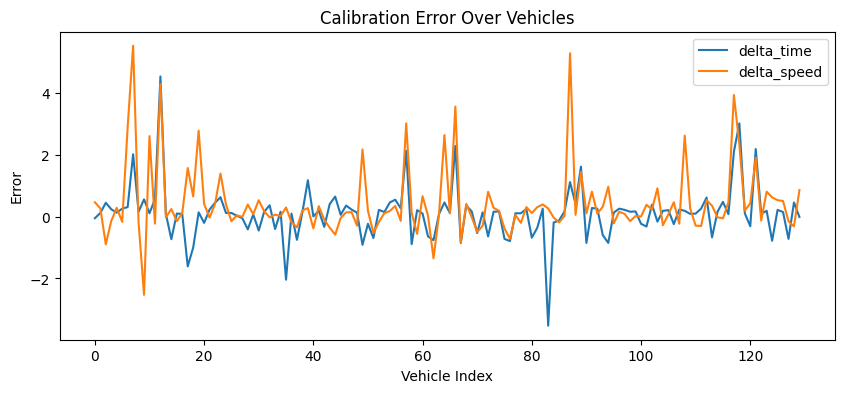

In [9]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df['delta_time'], label='delta_time')
plt.plot(df.index, df['delta_speed'], label='delta_speed')
plt.xlabel('Vehicle Index')
plt.ylabel('Error')
plt.title('Calibration Error Over Vehicles')
plt.legend()
plt.show()

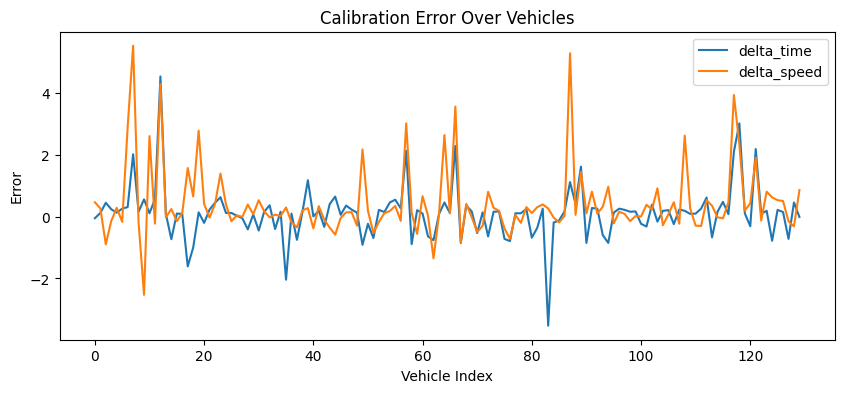

In [10]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df['delta_time'], label='delta_time')
plt.plot(df.index, df['delta_speed'], label='delta_speed')
plt.xlabel('Vehicle Index')
plt.ylabel('Error')
plt.title('Calibration Error Over Vehicles')
plt.legend()
plt.show()

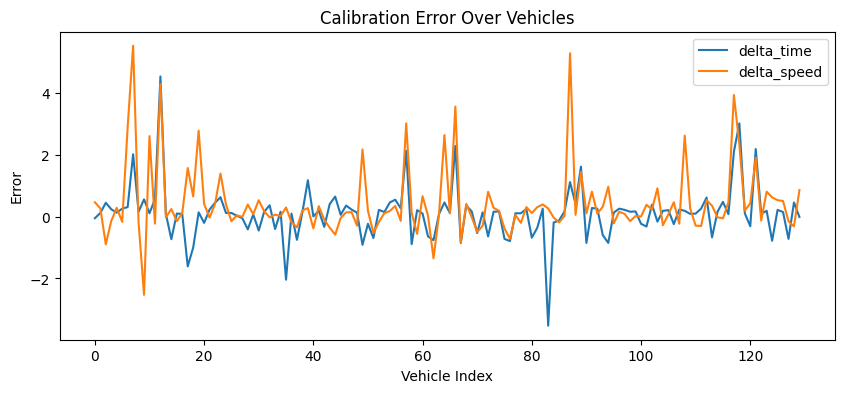

In [11]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df['delta_time'], label='delta_time')
plt.plot(df.index, df['delta_speed'], label='delta_speed')
plt.xlabel('Vehicle Index')
plt.ylabel('Error')
plt.title('Calibration Error Over Vehicles')
plt.legend()
plt.show()

4. Correlation Matrix

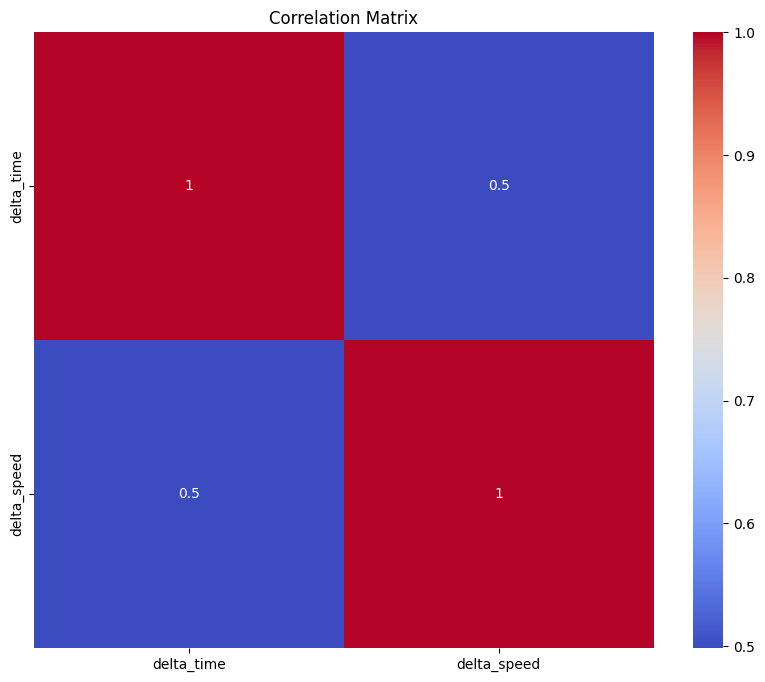

In [12]:
corr = df[["delta_time","delta_speed"]].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

5. Outlier Detection


In [13]:
for col in error_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
    print(f"Number of outliers in {col}: {len(outliers)}")
    display(outliers[[col]].head())

Number of outliers in delta_time: 14


,delta_time
7,2.02
12,4.54
17,-1.61
18,-1.00
35,-2.04


Number of outliers in delta_speed: 19


,delta_speed
6,2.893908
7,5.534136
9,-2.529933
10,2.608925
12,4.292981


6. Error by Speed Factor (if available)


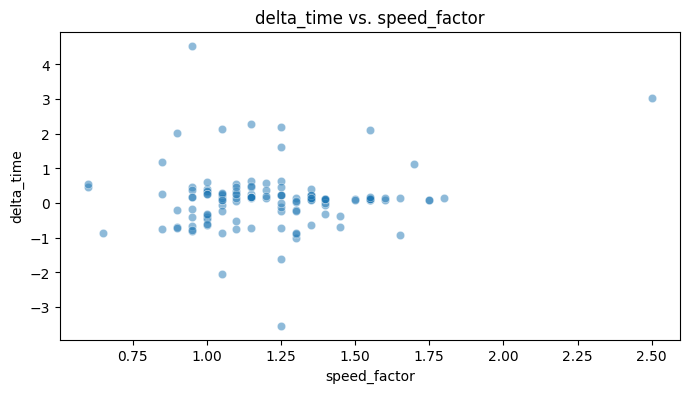

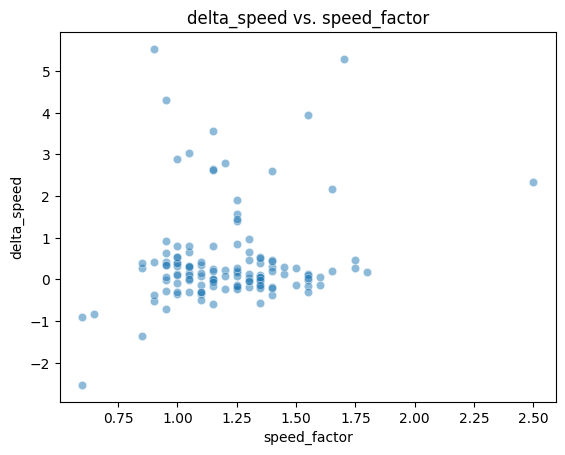

In [14]:
if 'speed_factor' in df.columns:
    plt.figure(figsize=(8,4))
    sns.scatterplot(x='speed_factor', y='delta_time', data=df, alpha=0.5)
    plt.title('delta_time vs. speed_factor')
    plt.show()
    sns.scatterplot(x='speed_factor', y='delta_speed', data=df, alpha=0.5)
    plt.title('delta_speed vs. speed_factor')
    plt.show()

7. Summary Table of Top N Largest Errors

In [15]:
N = 10
df['time_detector_sim'] = df['time_detector_sim'].apply(int)
print("Top N largest delta_time errors:")
display(df.nlargest(N, 'delta_time')[['veh_id', 'delta_speed', 'delta_time', 'time_detector_real', 'time_detector_sim']])
print("Top N largest delta_speed errors:")
display(df.nlargest(N, 'delta_speed')[['veh_id', 'delta_time', 'delta_speed', 'speed_detector_real', 'speed_detector_sim']])

Top N largest delta_time errors:


,veh_id,delta_speed,delta_time,time_detector_real,time_detector_sim
12,12_w2e_in,4.292981,4.54,1708316243,1708316247
118,118_w2e_in,2.335356,3.02,1708322143,1708322146
66,66_w2e_in,3.563722,2.29,1708320248,1708320250
121,121_w2e_in,1.910080,2.19,1708322174,1708322176
57,57_w2e_in,3.021983,2.13,1708319593,1708319595
117,117_w2e_in,3.939764,2.10,1708322142,1708322144
7,7_w2e_in,5.534136,2.02,1708315898,1708315900
89,89_w2e_in,1.450754,1.62,1708321416,1708321417
39,39_w2e_in,0.277406,1.18,1708318161,1708318162
87,87_w2e_in,5.291013,1.12,1708321366,1708321367


Top N largest delta_speed errors:


,veh_id,delta_time,delta_speed,speed_detector_real,speed_detector_sim
7,7_w2e_in,2.02,5.534136,0.833333,6.367469
87,87_w2e_in,1.12,5.291013,8.333333,13.624346
12,12_w2e_in,4.54,4.292981,2.777778,7.070758
117,117_w2e_in,2.10,3.939764,8.611111,12.550875
66,66_w2e_in,2.29,3.563722,5.000000,8.563722
57,57_w2e_in,2.13,3.021983,5.277778,8.299761
6,6_w2e_in,0.31,2.893908,4.166667,7.060575
19,19_w2e_in,0.14,2.786831,6.388889,9.175720
64,64_w2e_in,0.46,2.641917,6.388889,9.030806
108,108_w2e_in,0.19,2.623894,6.388889,9.012783


8. Save Plots to Disk


In [16]:
plt.figure(figsize=(8,4))
df['delta_time'].hist(bins=30)
plt.title('Histogram of delta_time')
plt.xlabel('delta_time')
plt.ylabel('Frequency')
plt.savefig('delta_time_histogram.png')
plt.close()